In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')

# zsq, 
#df = pd.read_csv("/content/drive/MyDrive/(mine)Deep Learning/data.csv")
# xyb, 
df = pd.read_csv("drive/MyDrive/Deep Learning Materials/Group Project/data.csv")
# files
# df = pd.read_csv("data.csv")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


# Data Processing Procudures

1. Drop NA
2. Drop a column with only single value
3. Change Categories

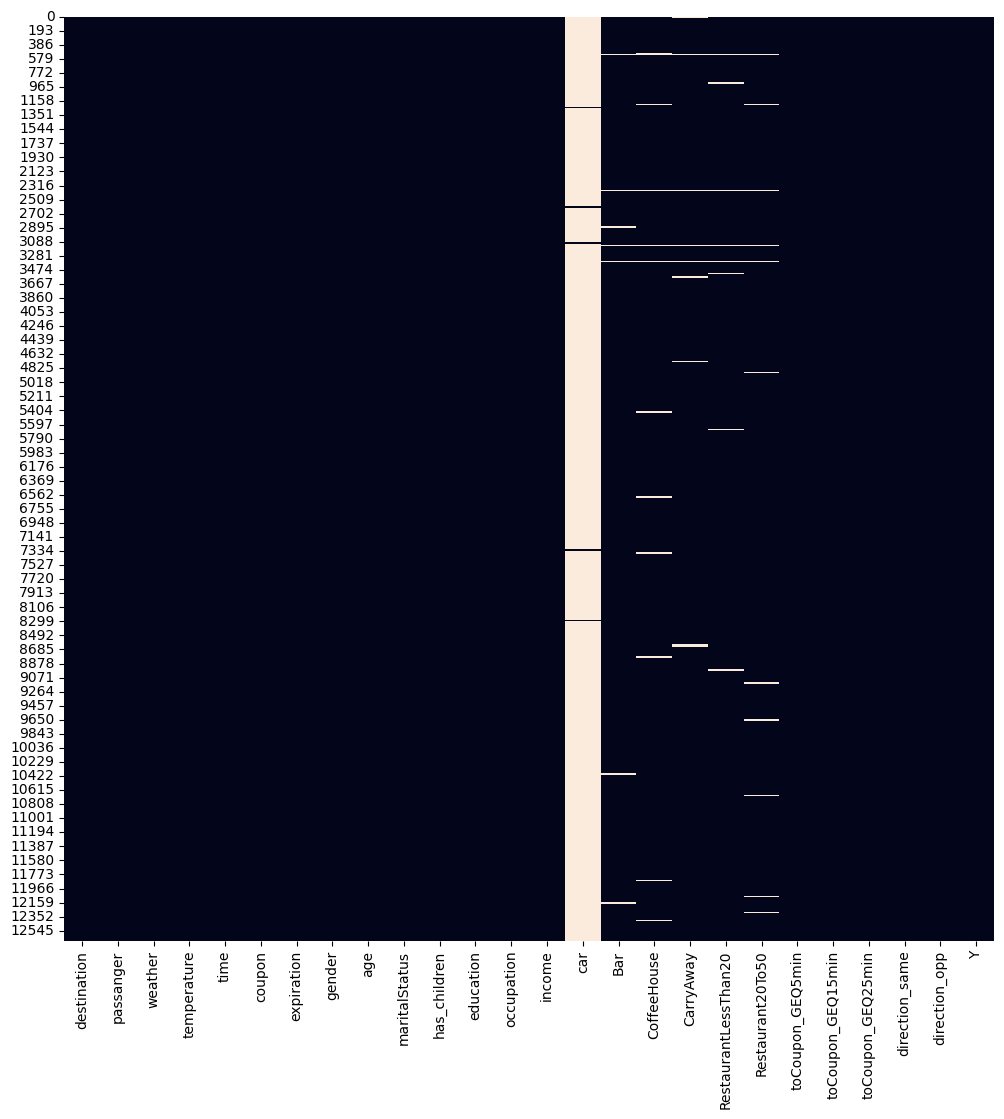

In [ ]:
ck1=check_situation(df)
heatmap1=draw_heatmap_of_missing_value(df)

In [ ]:
ck1

,data type,# unique value,# of missing value,# of non-missing value,value counts,1237,8297
destination,object,3,0,12684,"[No Urgent Place, Home, Work]",No Urgent Place,Work
passanger,object,4,0,12684,"[Alone, Friend(s), Kid(s), Partner]",Alone,Alone
weather,object,3,0,12684,"[Sunny, Rainy, Snowy]",Sunny,Sunny
temperature,int64,3,0,12684,"[55, 80, 30]",55,80
time,object,5,0,12684,"[2PM, 10AM, 6PM, 7AM, 10PM]",2PM,7AM
coupon,object,5,0,12684,"[Restaurant(<20), Coffee House, Carry out & Ta...",Restaurant(<20),Restaurant(<20)
expiration,object,2,0,12684,"[1d, 2h]",1d,1d
gender,object,2,0,12684,"[Female, Male]",Male,Male
age,object,8,0,12684,"[21, 46, 26, 31, 41, 50plus, 36, below21]",26,21
maritalStatus,object,5,0,12684,"[Unmarried partner, Single, Married partner, D...",Single,Single


## Checking and finding
1. Some features exist lots of missing value, so **dropping NA** is necessary
2. The feature named 'toCoupon_GEQ5min' has **1 unqiue value only**, which make no effort to the prediction and need to be dropped 
3. Some features owns **categorical value type**, which could be transformed conditionally


## Drop NA

In [ ]:
df = df.drop('car', axis=1)

In [ ]:
df = df.dropna(axis=0)
df = df.reset_index(drop=True)

In [ ]:
df.isna().sum()

destination             0
passanger               0
weather                 0
temperature             0
time                    0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Y                       0
dtype: int64

## Drop a column with only single value

In [ ]:
df.toCoupon_GEQ5min.value_counts()

1    12079
Name: toCoupon_GEQ5min, dtype: int64

In [ ]:
df = df.drop('toCoupon_GEQ5min', axis=1)

## Change Categories

- from categorical to numerical:

       'temperature', 'age','income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50'

- from categorical to dummy variable:

       'destination', 'passanger', 'weather', 'time', 'coupon',
       'expiration', 'gender', 'maritalStatus', 'has_children',
       'education', 'occupation', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'direction_opp'

In [ ]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'time', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'Bar', 'CoffeeHouse', 'CarryAway',
       'RestaurantLessThan20', 'Restaurant20To50', 'toCoupon_GEQ15min',
       'toCoupon_GEQ25min', 'direction_same', 'direction_opp', 'Y'],
      dtype='object')

In [ ]:
df.dtypes

destination             object
passanger               object
weather                 object
temperature              int64
time                    object
coupon                  object
expiration              object
gender                  object
age                     object
maritalStatus           object
has_children             int64
education               object
occupation              object
income                  object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
toCoupon_GEQ15min        int64
toCoupon_GEQ25min        int64
direction_same           int64
direction_opp            int64
Y                        int64
dtype: object

### from categorical to numerical

In [ ]:
numerical_variables = ['temperature', 'age','income', 'Bar', 'CoffeeHouse', 'CarryAway','RestaurantLessThan20', 'Restaurant20To50']

In [ ]:
df[numerical_variables].dtypes

temperature              int64
age                     object
income                  object
Bar                     object
CoffeeHouse             object
CarryAway               object
RestaurantLessThan20    object
Restaurant20To50        object
dtype: object

In [ ]:
age_value_map = {'below21': 21, '21':21, '26':26, '31':31, '36':36, '41':41, '46':46, '50plus': 50}
income_value_map = {'Less than $12500':12500,
                    '$12500 - $24999':18750,
                    '$25000 - $37499':31250,
                    '$37500 - $49999':43750,
                    '$50000 - $62499':56250,
                    '$62500 - $74999':68750,
                    '$75000 - $87499':81250,
                    '$87500 - $99999':93750,
                    '$100000 or More':100000}
Bar_value_map = {'never':0,'less1':1,'1~3':2, '4~8':6, 'gt8':8}
CoffeeHouse_value_map = {'never':0,'less1':1,'1~3':2, '4~8':6, 'gt8':8}
CarryAway_value_map = {'never':0,'less1':1,'1~3':2, '4~8':6, 'gt8':8}
RestaurantLessThan20_value_map = {'never':0,'less1':1,'1~3':2, '4~8':6, 'gt8':8}
Restaurant20To50_value_map = {'never':0,'less1':1,'1~3':2, '4~8':6, 'gt8':8}

In [ ]:
df['age'] = df['age'].replace(age_value_map)
df['income'] = df['income'].replace(income_value_map)
df['Bar'] = df['Bar'].replace(Bar_value_map)
df['CoffeeHouse'] = df['CoffeeHouse'].replace(CoffeeHouse_value_map)
df['CarryAway'] = df['CarryAway'].replace(CarryAway_value_map)
df['RestaurantLessThan20'] = df['RestaurantLessThan20'].replace(RestaurantLessThan20_value_map)
df['Restaurant20To50'] = df['Restaurant20To50'].replace(Restaurant20To50_value_map)

In [ ]:
df[numerical_variables].dtypes

temperature             int64
age                     int64
income                  int64
Bar                     int64
CoffeeHouse             int64
CarryAway               int64
RestaurantLessThan20    int64
Restaurant20To50        int64
dtype: object

### from categorical to dummy variable

In [ ]:
categorical_variables = [ 'destination', 'passanger', 'weather', 'time', 'coupon',
                         'expiration', 'gender', 'maritalStatus', 'has_children',
                         'education', 'occupation', 'toCoupon_GEQ15min',
                         'toCoupon_GEQ25min', 'direction_same', 'direction_opp']

In [ ]:
df[categorical_variables].dtypes

destination          object
passanger            object
weather              object
time                 object
coupon               object
expiration           object
gender               object
maritalStatus        object
has_children          int64
education            object
occupation           object
toCoupon_GEQ15min     int64
toCoupon_GEQ25min     int64
direction_same        int64
direction_opp         int64
dtype: object

In [ ]:
df = pd.get_dummies(df, columns=categorical_variables,drop_first=True)

## Rename the features for future analysis

In [ ]:
# move specific string in case the XGBoost in feature engineering can not regonize 
df = df.rename(columns={
     'passanger_Friend(s)': 'passanger_Friend',
     'passanger_Kid(s)': 'passanger_Kid',
     'coupon_Restaurant(20-50)': 'coupon_Restaurant between 20 and 50', 
     'coupon_Restaurant(<20)': 'coupon_Restaurant less than 20',
})

## Result of processing

In [ ]:
ck=check_situation(df)
print(df.shape)
ck.T

(12079, 64)


,temperature,age,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,Y,destination_No Urgent Place,...,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed,toCoupon_GEQ15min_1,toCoupon_GEQ25min_1,direction_same_1,direction_opp_1
data type,int64,int64,int64,int64,int64,int64,int64,int64,int64,uint8,...,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8,uint8
# unique value,3,7,9,5,5,5,5,5,2,2,...,2,2,2,2,2,2,2,2,2,2
# of missing value,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
# of non-missing value,12079,12079,12079,12079,12079,12079,12079,12079,12079,12079,...,12079,12079,12079,12079,12079,12079,12079,12079,12079,12079
value counts,"[55, 80, 30]","[21, 46, 26, 31, 41, 50, 36]","[68750, 18750, 81250, 56250, 43750, 31250, 100...","[0, 1, 2, 8, 6]","[1, 6, 2, 8, 0]","[6, 2, 8, 1, 0]","[6, 2, 1, 8, 0]","[1, 0, 2, 8, 6]","[1, 0]","[1, 0]",...,"[0, 1]","[0, 1]","[0, 1]","[0, 1]","[0, 1]","[0, 1]","[0, 1]","[0, 1]","[0, 1]","[1, 0]"
0,55,21,68750,0,1,6,6,1,1,1,...,0,0,0,0,0,0,0,0,0,1
12078,80,26,81250,0,0,2,6,2,0,0,...,0,0,1,0,0,0,0,0,1,0


## correlation matrix

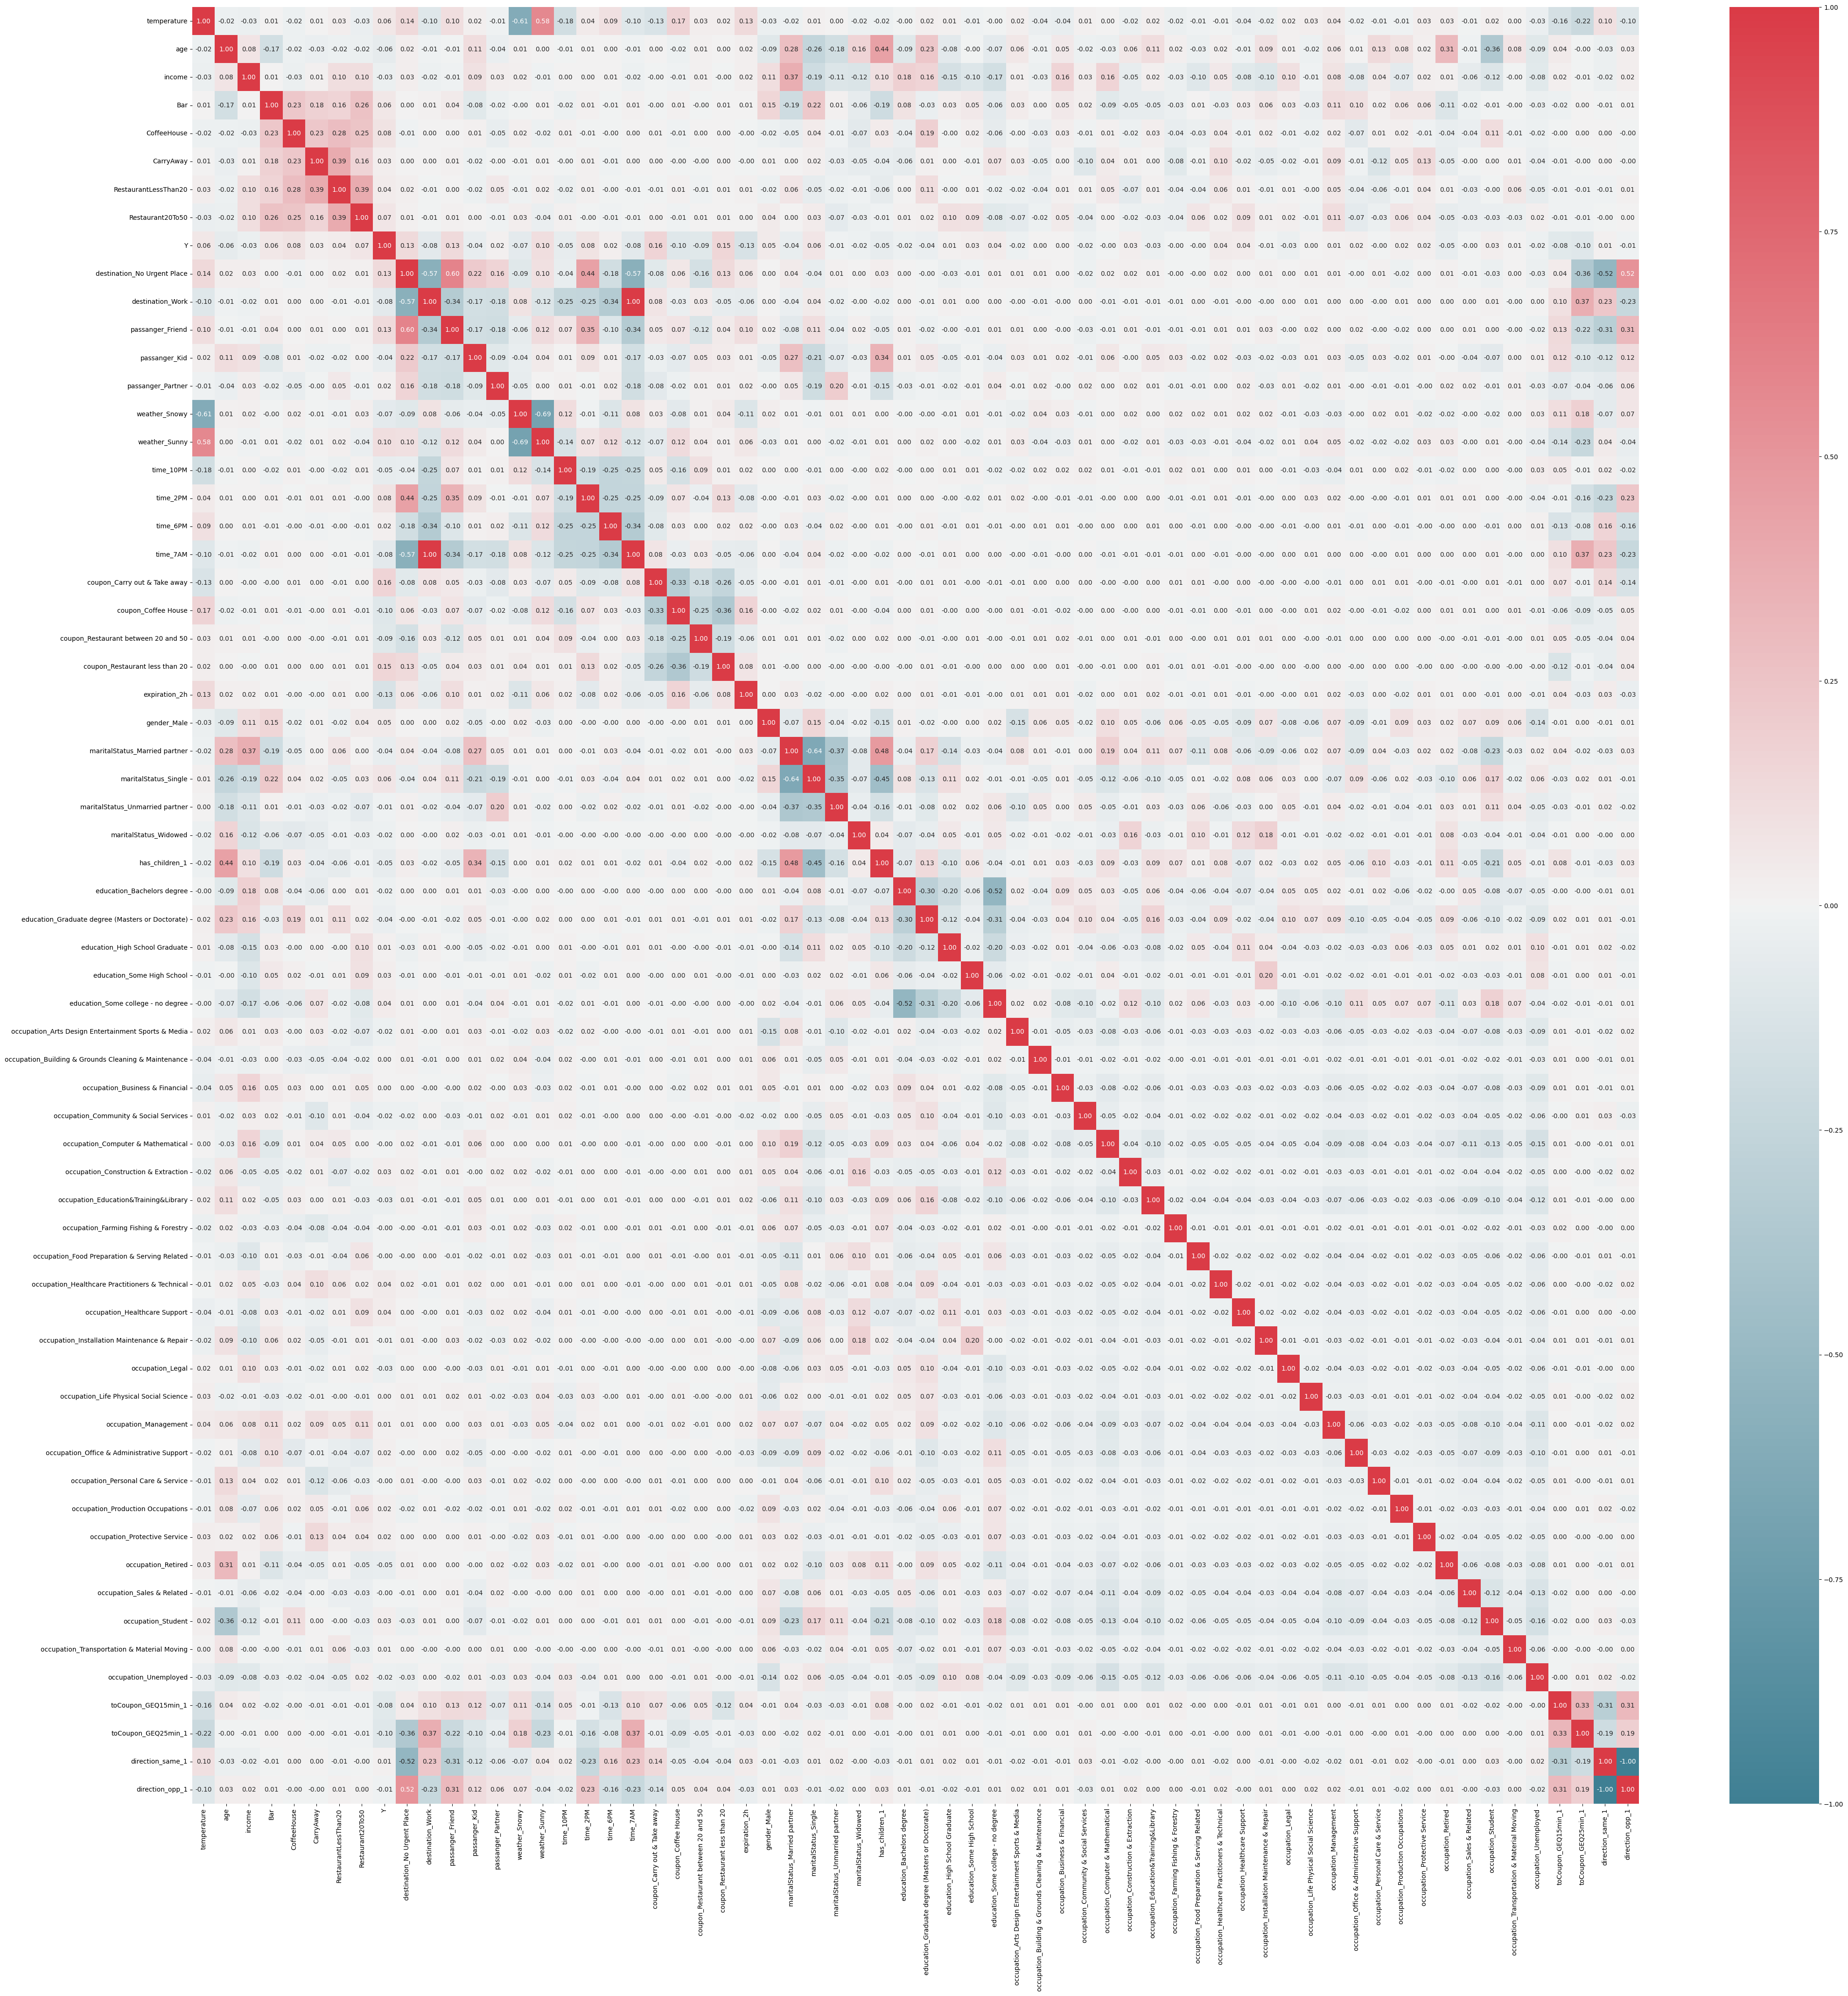

In [ ]:
plt.figure(figsize=(50,50))

# correletion matrix
cor = df.corr()

# Create a diverging color palette
cmap = sns.diverging_palette(220, 10, as_cmap=True)
# Plot a heatmap with diverging color palette
sns.heatmap(cor, annot=True, cmap=cmap, fmt=".2f")
plt.show()

In [ ]:
c=df.corr()["Y"].abs().sort_values(ascending=False)
c.iloc[c.values>c.mean()]

Y                                      1.000000
coupon_Carry out & Take away           0.164030
coupon_Restaurant less than 20         0.149646
expiration_2h                          0.133131
destination_No Urgent Place            0.129104
passanger_Friend                       0.128252
weather_Sunny                          0.102189
toCoupon_GEQ25min_1                    0.100542
coupon_Coffee House                    0.100191
coupon_Restaurant between 20 and 50    0.090793
toCoupon_GEQ15min_1                    0.081711
time_2PM                               0.080160
CoffeeHouse                            0.078610
time_7AM                               0.076287
destination_Work                       0.076287
Restaurant20To50                       0.067807
weather_Snowy                          0.066094
maritalStatus_Single                   0.064724
Name: Y, dtype: float64

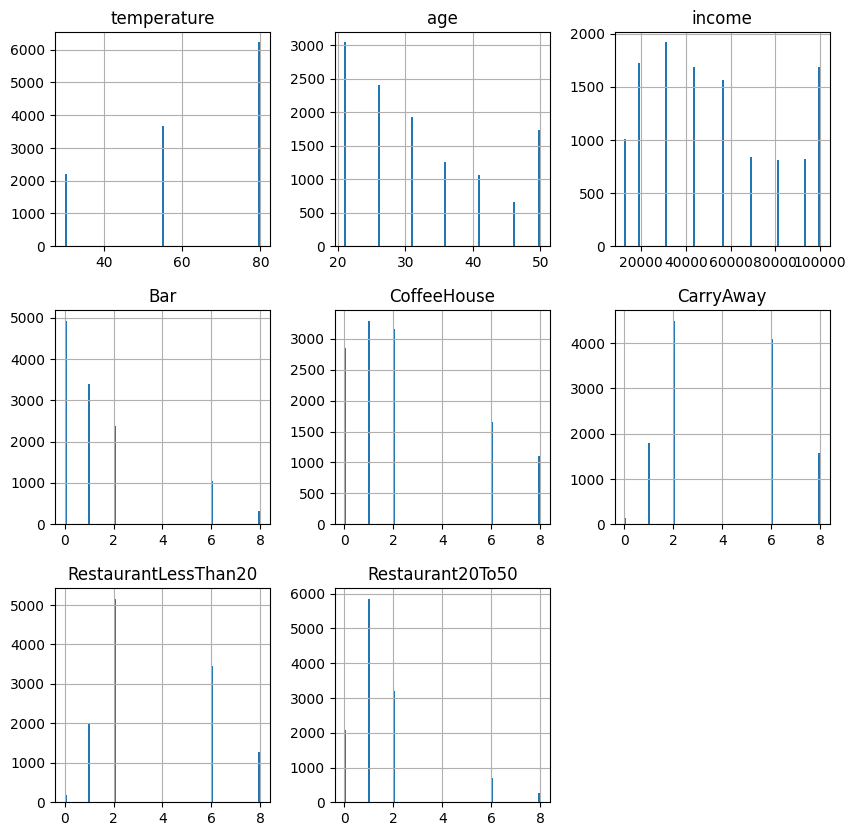

In [ ]:
# choice 1: show the histgram of all columns
# cols=c.index.values
# choice 2: show the histgram of numerical columns
# df.columns[0:8]
hist = df.hist(column=df.columns[0:8], figsize=(10,10),bins=100)

In [ ]:
# mask = (cor>=0.5 and cor<1)
# cor[mask]

def highlighter(cell_value):
  if cell_value**2 >= 0.5 :
    return "background-color: yellow"
  elif cell_value**2 <= 0.0001 :
    return "background-color: purple"

cor.style.applymap(highlighter)

,temperature,age,income,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,Y,destination_No Urgent Place,destination_Work,passanger_Friend,passanger_Kid,passanger_Partner,weather_Snowy,weather_Sunny,time_10PM,time_2PM,time_6PM,time_7AM,coupon_Carry out & Take away,coupon_Coffee House,coupon_Restaurant between 20 and 50,coupon_Restaurant less than 20,expiration_2h,gender_Male,maritalStatus_Married partner,maritalStatus_Single,maritalStatus_Unmarried partner,maritalStatus_Widowed,has_children_1,education_Bachelors degree,education_Graduate degree (Masters or Doctorate),education_High School Graduate,education_Some High School,education_Some college - no degree,occupation_Arts Design Entertainment Sports & Media,occupation_Building & Grounds Cleaning & Maintenance,occupation_Business & Financial,occupation_Community & Social Services,occupation_Computer & Mathematical,occupation_Construction & Extraction,occupation_Education&Training&Library,occupation_Farming Fishing & Forestry,occupation_Food Preparation & Serving Related,occupation_Healthcare Practitioners & Technical,occupation_Healthcare Support,occupation_Installation Maintenance & Repair,occupation_Legal,occupation_Life Physical Social Science,occupation_Management,occupation_Office & Administrative Support,occupation_Personal Care & Service,occupation_Production Occupations,occupation_Protective Service,occupation_Retired,occupation_Sales & Related,occupation_Student,occupation_Transportation & Material Moving,occupation_Unemployed,toCoupon_GEQ15min_1,toCoupon_GEQ25min_1,direction_same_1,direction_opp_1
temperature,1.000000,-0.015916,-0.028432,0.006251,-0.019942,0.007579,0.028649,-0.031257,0.056646,0.135593,-0.100924,0.104117,0.023154,-0.007919,-0.613128,0.577881,-0.175322,0.042412,0.094045,-0.100924,-0.126094,0.169124,0.025411,0.023914,0.125889,-0.027557,-0.019123,0.012574,0.003523,-0.018394,-0.020674,-0.002653,0.023116,0.008179,-0.010606,-0.000355,0.019981,-0.038910,-0.040671,0.013774,0.002705,-0.024435,0.016431,-0.024222,-0.012318,-0.007258,-0.036811,-0.024196,0.015395,0.025093,0.042292,-0.015085,-0.014518,-0.013151,0.025039,0.028614,-0.006236,0.021313,0.001886,-0.031422,-0.155876,-0.215780,0.097539,-0.097539
age,-0.015916,1.000000,0.077087,-0.166699,-0.022030,-0.033011,-0.017483,-0.024615,-0.055975,0.024515,-0.009586,-0.006040,0.113005,-0.036213,0.009041,0.001573,-0.005711,0.007112,0.004362,-0.009586,0.004776,-0.016779,0.013557,0.002812,0.019538,-0.090253,0.277184,-0.256335,-0.175445,0.163868,0.438160,-0.086898,0.234012,-0.077159,-0.001588,-0.066224,0.055611,-0.008546,0.048811,-0.020242,-0.026541,0.062087,0.113244,0.020229,-0.030431,0.022926,-0.009993,0.092876,0.011029,-0.020477,0.058566,0.005960,0.128210,0.080468,0.019142,0.307532,-0.009303,-0.363425,0.076635,-0.090309,0.041353,-0.001620,-0.029948,0.029948
income,-0.028432,0.077087,1.000000,0.007047,-0.025146,0.008749,0.103382,0.103232,-0.030819,0.026714,-0.015786,-0.014505,0.088330,0.030452,0.016914,-0.013493,0.000112,0.000652,0.007534,-0.015786,-0.003215,-0.012283,0.008233,-0.000102,0.017727,0.106191,0.367779,-0.192780,-0.113567,-0.120145,0.099246,0.180197,0.161431,-0.148513,-0.102201,-0.169314,0.010295,-0.030892,0.160144,0.027851,0.159206,-0.047839,0.015758,-0.030246,-0.099291,0.053239,-0.083965,-0.102028,0.098303,-0.011482,0.084081,-0.076790,0.040790,-0.066243,0.022972,0.012320,-0.061689,-0.117182,-0.001135,-0.081951,0.023188,-0.007148,-0.024226,0.024226
Bar,0.006251,-0.166699,0.007047,1.000000,0.230850,0.175775,0.162944,0.263567,0.058121,0.000354,0.009962,0.040108,-0.079134,-0.020427,-0.001252,0.006787,-0.019452,0.010579,-0.005248,0.009962,-0.003819,0.012915,-0.003106,0.005934,0.007681,0.148957,-0.191840,0.220010,0.013124,-0.057880,-0.191410,0.084523,-0.033389,0.029944,0.046880,-0.062860,0.034938,0.002634,0.047143,0.019826,-0.085622,-0.048201,-0.050171,-0.027153,0.005544,-0.029121,0.029143,0.059141,0.027015,-0.032674,0.112306,0.097325,0.017798,0.057668,0.059547,-0.111056,-0.017933,-0.006967,-0.00004

**Finding in the correaltion value**

* value == 1:  time_7AM + destination_Work
* value == -1:  direction_opp_1 + direction_same_1

so, drop features:  direction_opp_1 ,  destination_Work



In [ ]:
df1 = df.drop(columns=['direction_opp_1', 'destination_Work'], axis=1)

## Data Normalization

In [ ]:
# Define the scaler
scaler = MinMaxScaler()

# Apply the scaler only to the numeric columns
df1[numerical_variables] = scaler.fit_transform(df1[numerical_variables])

# Split dataset into train/validation/test set

In [ ]:


# Get X and y
#create X and y data set
y  = df1["Y"]
X  = df1.drop(columns=["Y"], axis=1)

# Split into training and test sets, seed=5240
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.10, random_state=5240)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.20, random_state=5240)

# *Export the csv file


In [ ]:
# cancat df
data_train = pd.concat([X_train, y_train], axis=1)
data_val = pd.concat([X_val, y_val], axis=1)
data_test = pd.concat([X_test, y_test], axis=1)

In [ ]:
data_train.to_csv('data_train.csv')
data_val.to_csv('data_val.csv')
data_test.to_csv('data_test.csv')